# 1. Setup & Connecting to the Database
First, let's install the necessary libraries and connect to the LanceDB table we created in our ingestion script.

In [ ]:
!pip install lancedb matplotlib Pillow -q


In [1]:
import lancedb
import matplotlib.pyplot as plt
from PIL import Image
import io
import numpy as np
import torch
import pickle
from transformers import CLIPProcessor, CLIPModel, AutoTokenizer, AutoModel
from pycocotools import mask as coco_mask

In [2]:
# Connect to the LanceDB database
db = lancedb.connect("lance_tables")

# Open the table we created during ingestion
tbl = db.open_table("coco")
print(f"Opened table '{tbl.name}' with {len(tbl)} rows.")

Opened table 'coco' with 123287 rows.


In [3]:
tbl.schema

image_embedding: fixed_size_list<item: float>[512]
  child 0, item: float
text_embedding: fixed_size_list<item: float>[768]
  child 0, item: float
image_bytes: binary
thumbnail_bytes: binary
image_path: string
file_name: string
height: int32
width: int32
coco_url: string
flickr_url: string
date_captured: string
captions: list<item: string>
  child 0, item: string
image_id: int64
split: string
bounding_boxes: list<item: list<item: float>>
  child 0, item: list<item: float>
      child 0, item: float
object_classes: list<item: string>
  child 0, item: string
stuff_classes: list<item: string>
  child 0, item: string
object_areas: list<item: double>
  child 0, item: double
instance_masks: list<item: struct<segmentation: binary, category_id: int64>>
  child 0, item: struct<segmentation: binary, category_id: int64>
      child 0, segmentation: binary
      child 1, category_id: int64
stuff_masks: list<item: struct<segmentation: binary, category_id: int64>>
  child 0, item: struct<segmentatio

# Setup embedding models
Let's initialze models that we'll use for both text and multimodal clip based dense vector search

In [4]:
# Initialize the same models we used during ingestion

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


clip_model = CLIPModel.from_pretrained('openai/clip-vit-base-patch32').to(device)
clip_processor = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')

text_tokenizer = AutoTokenizer.from_pretrained('BAAI/bge-base-en-v1.5')
text_model = AutoModel.from_pretrained('BAAI/bge-base-en-v1.5').to(device)

def embed_image(image: Image.Image):
    """Helper function to embed an image."""
    inputs = clip_processor(images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        embedding = clip_model.get_image_features(**inputs)
    return embedding.squeeze().cpu().numpy()


def embed_text(text):
    """Helper function to embed a text query."""
    # Add the instruction prefix required by the BGE model
    text_with_instruction = f"Represent this sentence for searching relevant passages: {text}"
    encoded = text_tokenizer(text_with_instruction, padding=True, truncation=True, return_tensors='pt', max_length=512)
    encoded = {k: v.to(device) for k, v in encoded.items()}
    with torch.no_grad():
        output = text_model(**encoded)
        embedding = output.last_hidden_state[:, 0]
    return embedding.squeeze().cpu().numpy()

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


# Dense vector search with metadata pre/post filter

In [5]:
query = "a cat sleeping on a couch"
query_vector = embed_text(query)

where_clause = "split = 'train' AND num_objects >= 3"

filtered_results = (
    tbl.search(query_vector, vector_column_name="text_embedding")
    .where(where_clause, prefilter=True)  # Set pre or post filter
    .limit(5)
    .to_pandas()
)

filtered_results[['image_id', 'captions', 'split', 'num_objects', 'image_bytes']]

,image_id,captions,split,num_objects,image_bytes
0,245006,[A cat laying on top of a couch on top of a pi...,train,3,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...
1,480566,"[A tired cat laying on a sofa sleeping. , A ca...",train,3,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...
2,226220,"[A cat is sleeping on the arm of a couch., a c...",train,7,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...
3,3999,[The cat is taking a nap on the back of the co...,train,4,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...
4,379226,"[A cat that is lying down on a couch., The cat...",train,3,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...


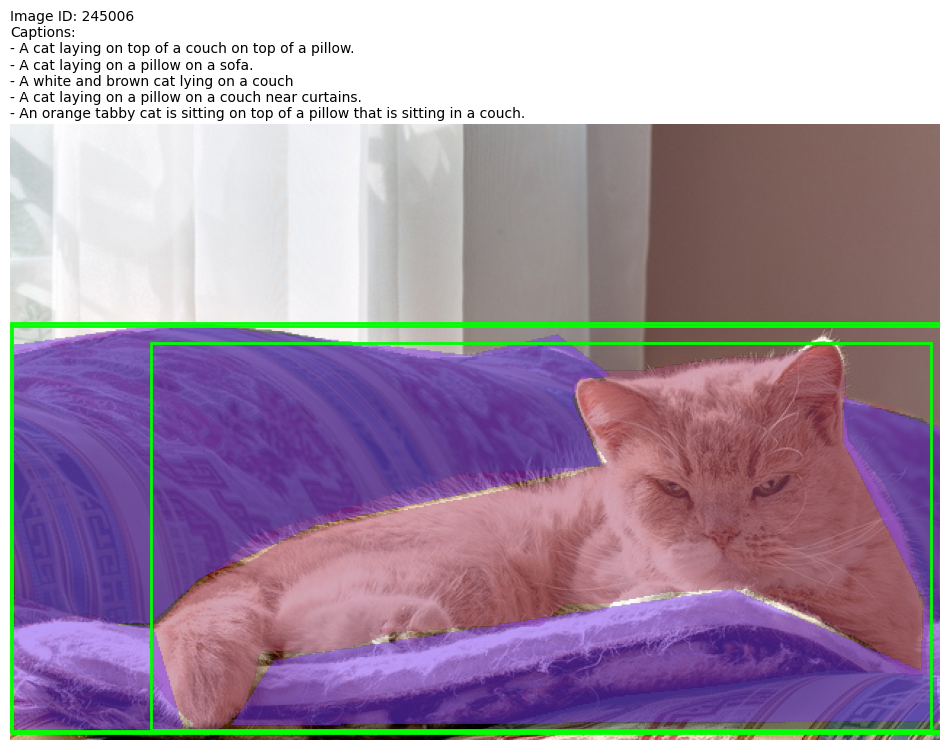

In [6]:
# display some images to test
from utils import coordinates_to_mask, display_result

# Visualize the first result from our filtered search
first_result_row = filtered_results.iloc[0]
display_result(first_result_row)

## More complex metadata filering

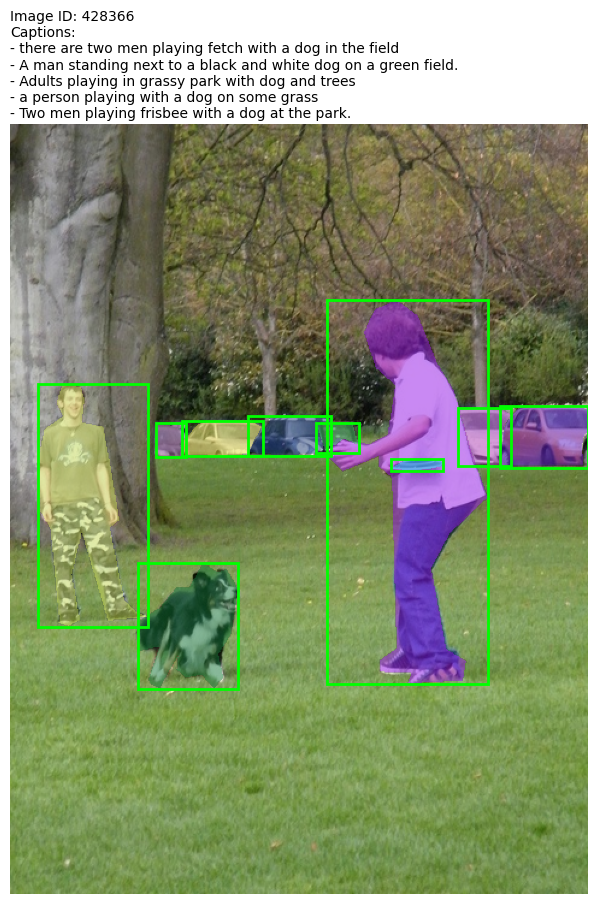

In [7]:
query = "a person playing with their dog outdoors"
where_clause = """
(height > 480) 
    AND 
array_contains(object_classes, 'person') 
    AND 
array_contains(object_classes, 'dog')
    AND
(num_objects >= 4)
"""
query_vector = embed_text(query)

complex_results = (
    tbl.search(query_vector, vector_column_name="text_embedding")
    .where(where_clause, prefilter=True)
    .limit(5)
    .to_pandas()
)

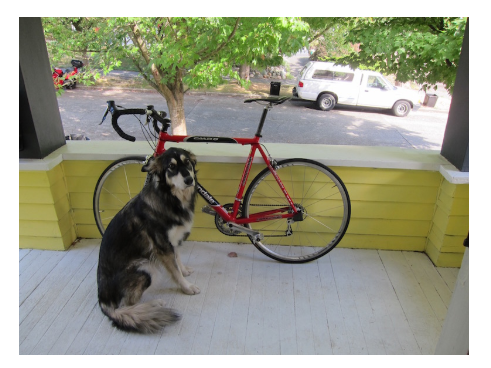

In [11]:
img = Image.open("img.png")
img

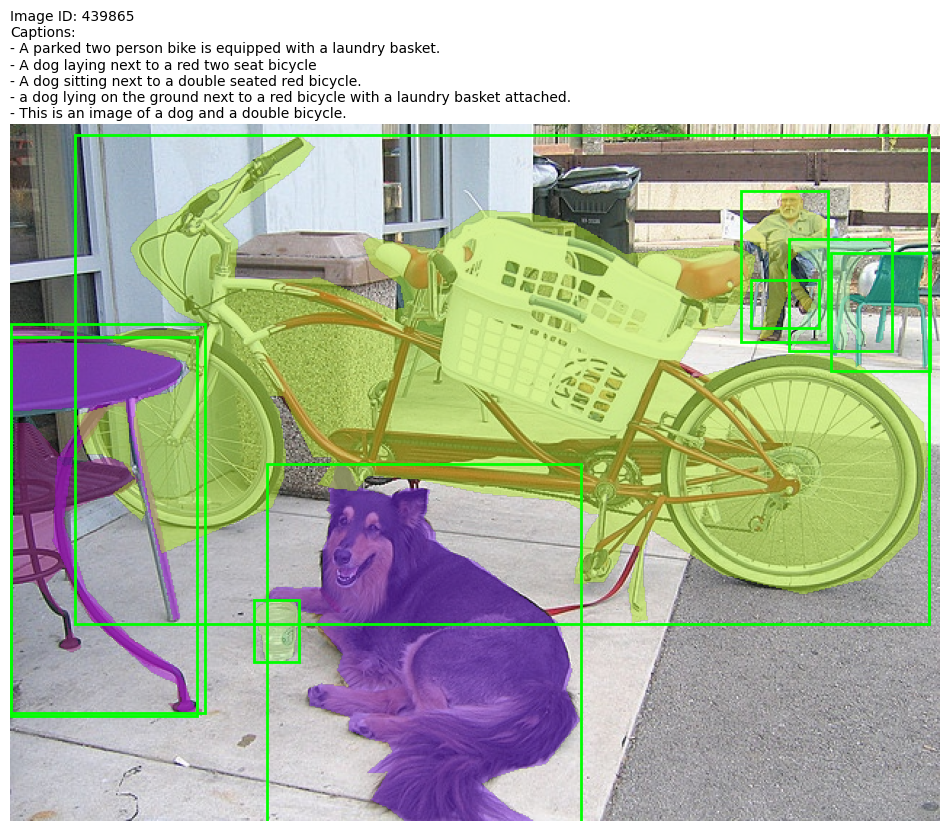

In [10]:
img = Image.open("img.png")
emb = embed_image(img)

where_clause = """
array_contains(object_classes, 'bicycle') 
    AND 
array_contains(object_classes, 'dog')
    AND
(num_objects >= 4)
"""
query_vector = embed_text(query)

complex_results = (
    tbl.search(emb, vector_column_name="image_embedding").where(where_clause, prefilter=True).limit(5).to_pandas()
)

top_result_row = complex_results.iloc[0]
display_result(top_result_row)


## Create Pytorch Dataloader from Lance dataset

In [14]:
import torch
import lance.torch.data

# Load lance dataset into a PyTorch IterableDataset.
# with only columns "image_embedding", "height".
dataset = lance.torch.data.LanceDataset(
    "lance_tables/coco.lance",
    columns=["image_embedding", "height"], # choose some random columns or all of them
    batch_size=128,
    batch_readahead=8,  # Control multi-threading reads.
)

# Create a PyTorch DataLoader
dataloader = torch.utils.data.DataLoader(dataset)

# Inference loop
for batch in dataloader:
    print(batch.keys())
    break

dict_keys(['image_embedding', 'height'])
